<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/adultwithpipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the adult Dataset Using Pandas

In [4]:
import pandas as pd
df = pd.read_csv('adult.csv')
# Load the dataset from the provided file path (adjust if needed)
df = pd.read_csv('adult.csv')

# Display the first few rows and basic info to verify loading
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nData Types and Non-Null Counts:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe(include='all'))

   age          workclass  fnlwgt   education  education-num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital-status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital-gain  capital-loss  hours-per-week  native-country  target  
0          2174             0              40   United-States   <=50

###Step 2 - Handle Missing Values and Basic Cleaning
### The dataset contains '?' as missing values (not detected as NaN by default). We'll replace them with NaN, drop rows with missing values, and strip whitespace from strings to ensure consistency.

In [5]:
# Replace '?' with NaN
df.replace('?', pd.NA, inplace=True)

# Check for NaN values after replacement
print("\nMissing Values After Replacement:")
print(df.isna().sum())

# Drop rows with any NaN (simple approach; alternatively, impute if preferred)
df = df.dropna()

# Strip whitespace from all object columns
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df[col] = df[col].str.strip()

# Verify changes
print("\nDataset Shape After Cleaning:", df.shape)
print("\nUnique Values in Target Column:", df['target'].unique())


Missing Values After Replacement:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
target            0
dtype: int64

Dataset Shape After Cleaning: (32561, 15)

Unique Values in Target Column: ['<=50K' '>50K']


### Step 3 - Split the Dataset into Training and Test Sets
### split the dataset into training and test sets. We'll define features (X) and target (y), encode y as binary (1 for '>50K', 0 for '<=50K'), and split the data.

In [6]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df.drop('target', axis=1)
y = df['target'].apply(lambda x: 1 if x.strip() == '>50K' else 0)  # Strip spaces and encode target

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify shapes and class distribution
print("\nTraining Set Shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Test Set Shape (X_test, y_test):", X_test.shape, y_test.shape)
print("\nClass Distribution in y_train:")
print(y_train.value_counts(normalize=True))


Training Set Shape (X_train, y_train): (26048, 14) (26048,)
Test Set Shape (X_test, y_test): (6513, 14) (6513,)

Class Distribution in y_train:
target
0    0.759291
1    0.240709
Name: proportion, dtype: float64


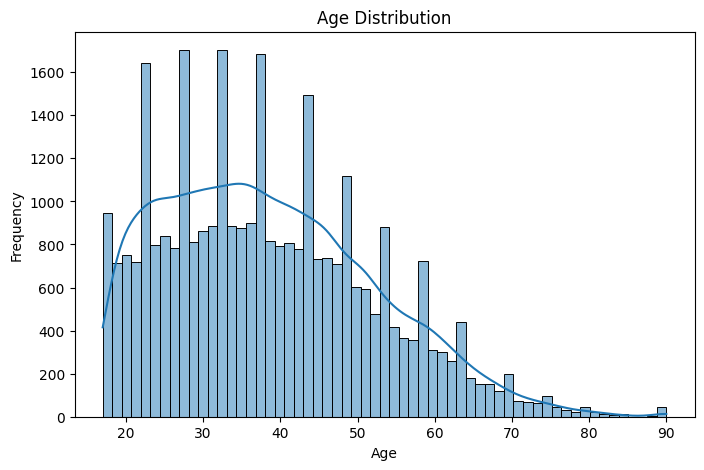

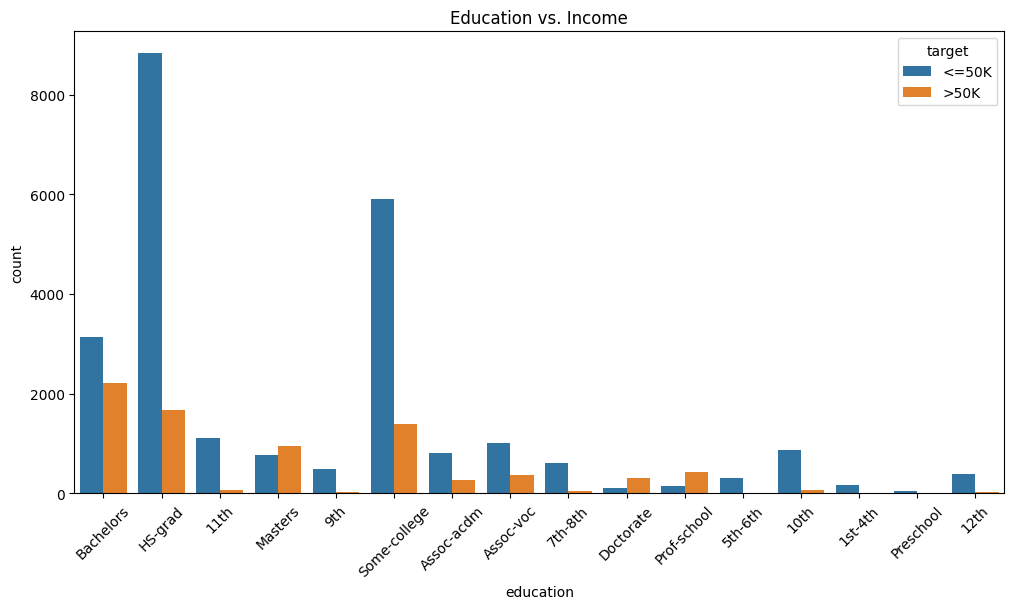

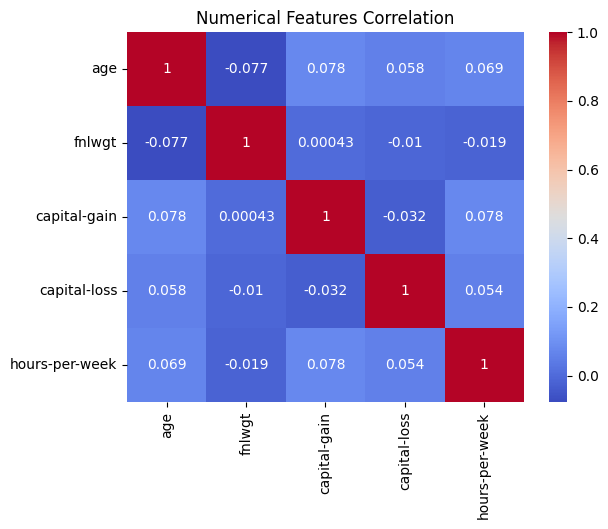

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numerical features distribution (example: age)
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Categorical feature example: education vs. target
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='education', hue='target')
plt.title('Education vs. Income')
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap for numerical features
numerical_cols = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Numerical Features Correlation')
plt.show()